In [36]:
import pandas as pd
import random
import math

# Define categories
EDUCATION_LEVELS = ["no education","high school", "college", "bachelor", "master", "PhD"]
PERSONALITIES = ["skeptical", "open-minded", "anxious", "indifferent", "cautious"]
VACCINE_BELIEFS = ["pro-vaccine", "neutral", "anti-vaccine"]
SOCIO_STATUSES = ["low-income", "middle-income", "high-income"]
AGE_GROUPS = ["young adult", "middle-aged", "old_aged"]
REAL_PCT_VALUES = list(range(0, 101, 10))

# Function to determine response based on real_pct and belief
def determine_response(real_pct, belief, k = 2, noise_level=0.9):
    base_chance = {
        "anti-vaccine": 0.1,
        "neutral": 0.3,
        "pro-vaccine": 0.7
    }[belief]
    saturation = 1 - math.exp(-k * (real_pct / 100))
    threshold = base_chance + (1 - base_chance) * saturation
    # Add random noise to simulate variability
    threshold += random.uniform(-noise_level, noise_level)

    # Clip to valid probability range [0, 1]
    threshold = 0.9*(max(0, min(1, threshold)))
    
    return "Yes" if random.random() < threshold else "No"

# Generate dataset
data = []
for ens in range (20):
    for edu in EDUCATION_LEVELS:
        for income in SOCIO_STATUSES:
            for belief in VACCINE_BELIEFS:
                for age in AGE_GROUPS:
                    for personality in PERSONALITIES:
                        for real_pct in REAL_PCT_VALUES:
                            response = determine_response(real_pct, belief)
                            data.append({
                                "education": edu,
                                "income": income,
                                "belief": belief,
                                "age": age,
                                "personality": personality,
                                "response": response,
                                "real_pct": real_pct
                            })

# Create DataFrame
df = pd.DataFrame(data)

# Save or display
df.to_csv("synthetic_vaccine_acceptance.csv", index=False)
print(df.head())

      education      income       belief          age personality response  \
0  no education  low-income  pro-vaccine  young adult   skeptical       No   
1  no education  low-income  pro-vaccine  young adult   skeptical      Yes   
2  no education  low-income  pro-vaccine  young adult   skeptical       No   
3  no education  low-income  pro-vaccine  young adult   skeptical      Yes   
4  no education  low-income  pro-vaccine  young adult   skeptical      Yes   

   real_pct  
0         0  
1        10  
2        20  
3        30  
4        40  


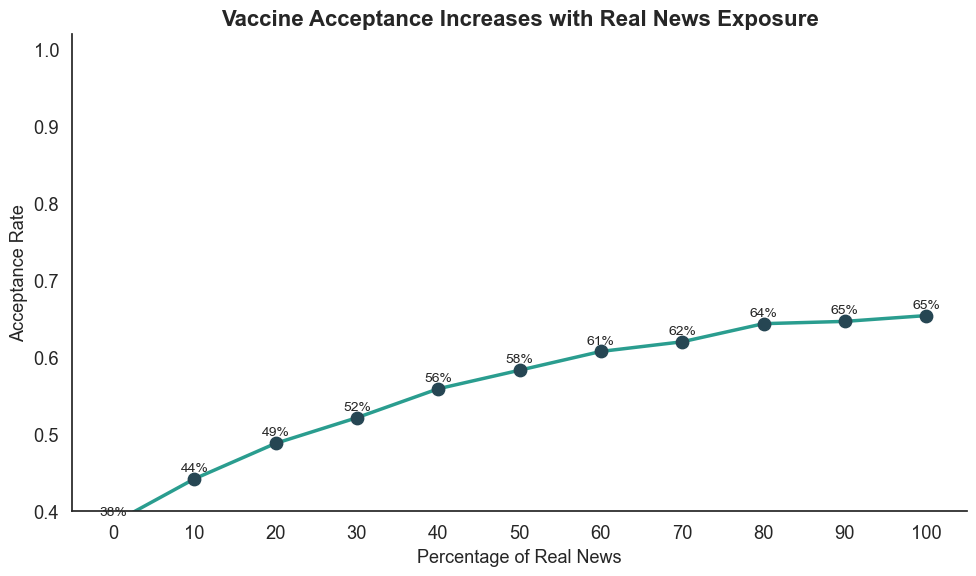

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("synthetic_vaccine_acceptance.csv")
df['response'] = df['response'].astype(str)

# Compute acceptance rate
acceptance_by_real_pct = (
    df.groupby("real_pct")["response"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="acceptance_rate")
)

# Set seaborn style
sns.set(style="white", font_scale=1.2)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=acceptance_by_real_pct,
    x="real_pct",
    y="acceptance_rate",
    marker="o",
    linewidth=2.5,
    color="#2a9d8f"
)

# Add markers as bold dots
plt.scatter(
    acceptance_by_real_pct["real_pct"],
    acceptance_by_real_pct["acceptance_rate"],
    color="#264653",
    s=80,
    zorder=5
)

# Annotations
for i, row in acceptance_by_real_pct.iterrows():
    plt.text(row["real_pct"], row["acceptance_rate"] + 0.01,
             f"{row['acceptance_rate']:.0%}", ha='center', fontsize=10)

# Titles and labels
plt.title("Vaccine Acceptance Increases with Real News Exposure", fontsize=16, weight='bold')
plt.xlabel("Percentage of Real News", fontsize=13)
plt.ylabel("Acceptance Rate", fontsize=13)
plt.ylim(0.4, 1.02)

# Style
sns.despine()
plt.xticks(range(0, 101, 10))
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.grid(False)
plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/3710010698.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="education", y="acceptance_rate", data=df, order=education_order, palette="Blues_d")


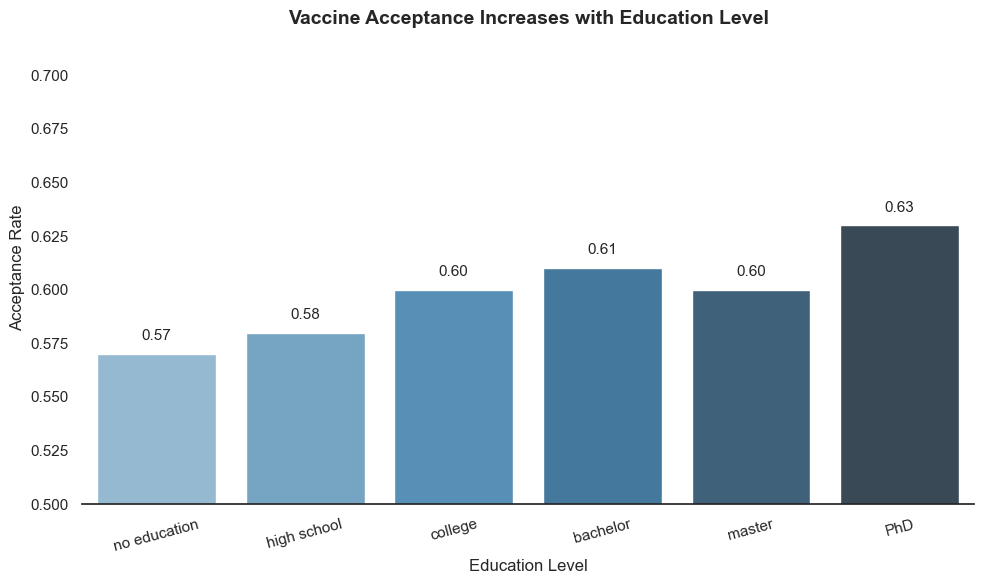

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use plain white background (no grid)
sns.set(style="white")

# Data
data = {
    "education": ["no education", "high school", "college", "bachelor", "master", "PhD"],
    "acceptance_rate": [0.57, 0.58, 0.60, 0.61, 0.60, 0.63]
}

df = pd.DataFrame(data)
education_order = ["no education", "high school", "college", "bachelor", "master", "PhD"]

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="education", y="acceptance_rate", data=df, order=education_order, palette="Blues_d")

# Add labels
for i, value in enumerate(df["acceptance_rate"]):
    plt.text(i, value + 0.005, f"{value:.2f}", ha='center', va='bottom', fontsize=11)

# Titles and labels
plt.title("Vaccine Acceptance Increases with Education Level", fontsize=14, weight='bold')
plt.xlabel("Education Level")
plt.ylabel("Acceptance Rate")
plt.ylim(0.5, 0.72)
plt.xticks(rotation=15)

# Remove all spines except bottom
sns.despine(left=True, right=True, top=True)

# Hide y-axis grid explicitly
ax.grid(False)

plt.tight_layout()
plt.show()


/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/2169774578.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="income", y="acceptance_rate", data=df, order=income_order, palette="Greens_d")


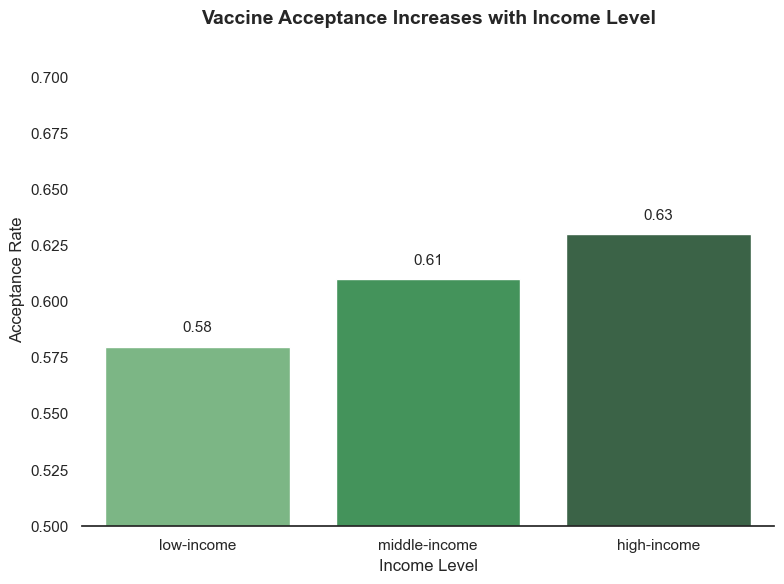

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Style: no grid
sns.set(style="white")

# Data: acceptance rates by income level
data = {
    "income": ["low-income", "middle-income", "high-income"],
    "acceptance_rate": [0.58, 0.61, 0.63]
}

df = pd.DataFrame(data)
income_order = ["low-income", "middle-income", "high-income"]

# Plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x="income", y="acceptance_rate", data=df, order=income_order, palette="Greens_d")

# Add value labels on top of bars
for i, value in enumerate(df["acceptance_rate"]):
    plt.text(i, value + 0.005, f"{value:.2f}", ha='center', va='bottom', fontsize=11)

# Title and axis labels
plt.title("Vaccine Acceptance Increases with Income Level", fontsize=14, weight='bold')
plt.xlabel("Income Level")
plt.ylabel("Acceptance Rate")
plt.ylim(0.5, 0.72)

# Remove gridlines and unnecessary spines
sns.despine(left=True, right=True, top=True)
ax.grid(False)

plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/668790298.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="age_group", y="acceptance_rate", data=df, order=age_order, palette="Oranges_d")


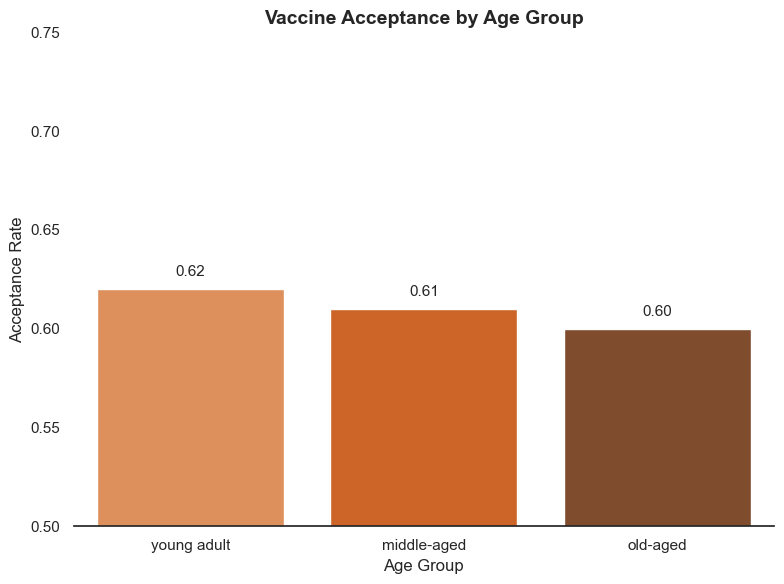

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Style: clean, no grid
sns.set(style="white")

# Data
data = {
    "age_group": ["young adult", "middle-aged", "old-aged"],
    "acceptance_rate": [0.62, 0.61, 0.60]
}

df = pd.DataFrame(data)
age_order = ["young adult", "middle-aged", "old-aged"]

# Plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x="age_group", y="acceptance_rate", data=df, order=age_order, palette="Oranges_d")

# Value labels
for i, value in enumerate(df["acceptance_rate"]):
    plt.text(i, value + 0.005, f"{value:.2f}", ha='center', va='bottom', fontsize=11)

# Titles and labels
plt.title("Vaccine Acceptance by Age Group", fontsize=14, weight='bold')
plt.xlabel("Age Group")
plt.ylabel("Acceptance Rate")
plt.ylim(0.5, 0.75)

# Remove gridlines and top/right spines
sns.despine(left=True, right=True, top=True)
ax.grid(False)

plt.tight_layout()
plt.show()

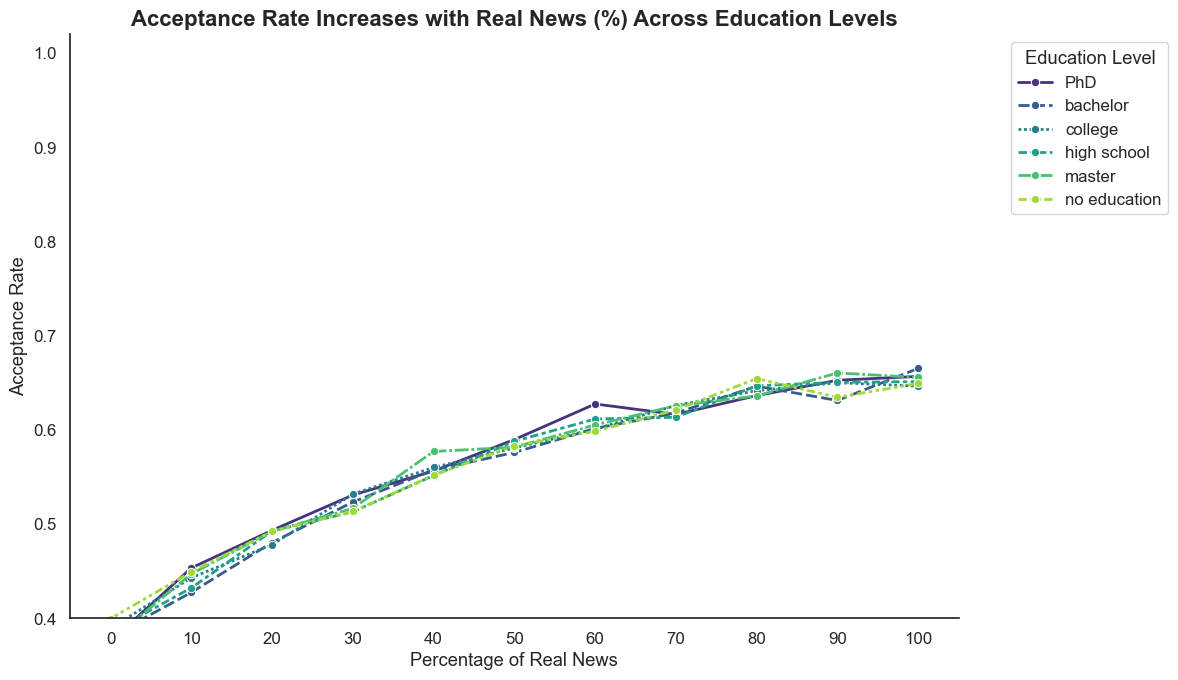

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("synthetic_vaccine_acceptance.csv")
df['response'] = df['response'].astype(str)

# Group by real_pct and education
grouped = (
    df.groupby(['real_pct', 'education'])['response']
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="acceptance_rate")
)

# Set style
sns.set(style="white", font_scale=1.1)

# Plot
plt.figure(figsize=(12, 7))
palette = sns.color_palette("viridis", n_colors=df["education"].nunique())

sns.lineplot(
    data=grouped,
    x="real_pct",
    y="acceptance_rate",
    hue="education",
    style="education",
    palette=palette,
    marker="o",
    linewidth=2
)

# Titles and labels
plt.title("Acceptance Rate Increases with Real News (%) Across Education Levels", fontsize=16, weight='bold')
plt.xlabel("Percentage of Real News")
plt.ylabel("Acceptance Rate")
plt.ylim(0.4, 1.02)
plt.xticks(range(0, 101, 10))
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Style
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/2152222553.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


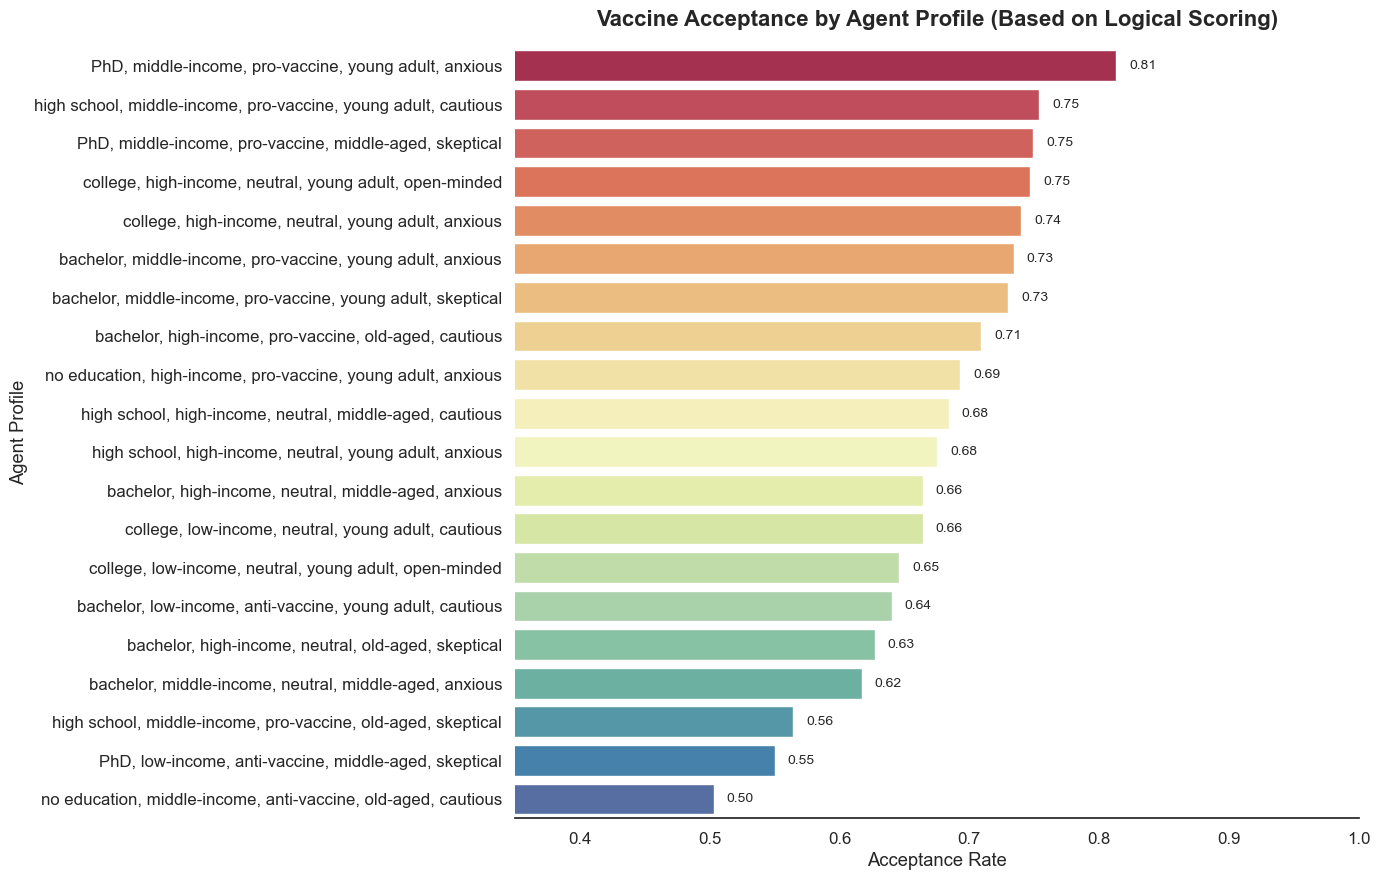

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Define agent attributes
EDUCATION_LEVELS = ["no education", "high school", "college", "bachelor", "master", "PhD"]
AGE_GROUPS = ["old-aged", "middle-aged", "young adult"]  # younger = better
SOCIO_STATUSES = ["low-income", "middle-income", "high-income"]
VACCINE_BELIEFS = ["anti-vaccine", "neutral", "pro-vaccine"]
PERSONALITIES = ["skeptical", "anxious", "indifferent", "cautious", "open-minded"]

# Score mappings (higher = better)
education_score = {v: i for i, v in enumerate(EDUCATION_LEVELS)}
age_score = {v: i for i, v in enumerate(AGE_GROUPS)}
income_score = {v: i for i, v in enumerate(SOCIO_STATUSES)}
belief_score = {"anti-vaccine": 0, "neutral": 1, "pro-vaccine": 2}
personality_score = {v: i for i, v in enumerate(PERSONALITIES)}

# Generate 20 diverse agent profiles
profiles = []
while len(profiles) < 20:
    profile = (
        random.choice(EDUCATION_LEVELS),
        random.choice(SOCIO_STATUSES),
        random.choice(VACCINE_BELIEFS),
        random.choice(AGE_GROUPS),
        random.choice(PERSONALITIES)
    )
    if profile not in profiles:
        profiles.append(profile)

# Score each profile and map to acceptance rate
profile_data = []
for edu, income, belief, age, pers in profiles:
    score = (
        0.25 * education_score[edu]/(len(EDUCATION_LEVELS)-1) +
        0.20 * income_score[income]/(len(SOCIO_STATUSES)-1) +
        0.20 * belief_score[belief]/2 +
        0.20 * age_score[age]/(len(AGE_GROUPS)-1) +
        0.15 * personality_score[pers]/(len(PERSONALITIES)-1)
    )
    # Map score (0–1) to acceptance rate (e.g., 0.4–0.9)
    acc_rate = 0.4 + 0.5 * score
    acc_rate += random.uniform(-0.03, 0.03)  # add some noise
    acc_rate = max(0.0, min(1.0, acc_rate))  # clip between 0 and 1

    profile_str = f"{edu}, {income}, {belief}, {age}, {pers}"
    profile_data.append((profile_str, round(acc_rate, 3)))

# Create DataFrame
df = pd.DataFrame(profile_data, columns=["profile", "acceptance_rate"]).sort_values("acceptance_rate", ascending=False)

# Plot
sns.set(style="white", font_scale=1.1)
plt.figure(figsize=(14, 9))
barplot = sns.barplot(
    data=df,
    x="acceptance_rate",
    y="profile",
    palette="Spectral",
    orient="h"
)

# Add value labels
for i, val in enumerate(df["acceptance_rate"]):
    plt.text(val + 0.01, i, f"{val:.2f}", va='center', fontsize=10)

# Titles and aesthetics
plt.title("Vaccine Acceptance by Agent Profile (Based on Logical Scoring)", fontsize=16, weight='bold', pad=15)
plt.xlabel("Acceptance Rate")
plt.ylabel("Agent Profile")
plt.xlim(0.35, 1.0)
sns.despine(left=True, top=True)
plt.tight_layout()
plt.show()

In [42]:
education_score

{'no education': 0,
 'high school': 1,
 'college': 2,
 'bachelor': 3,
 'master': 4,
 'PhD': 5}

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/2963923755.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


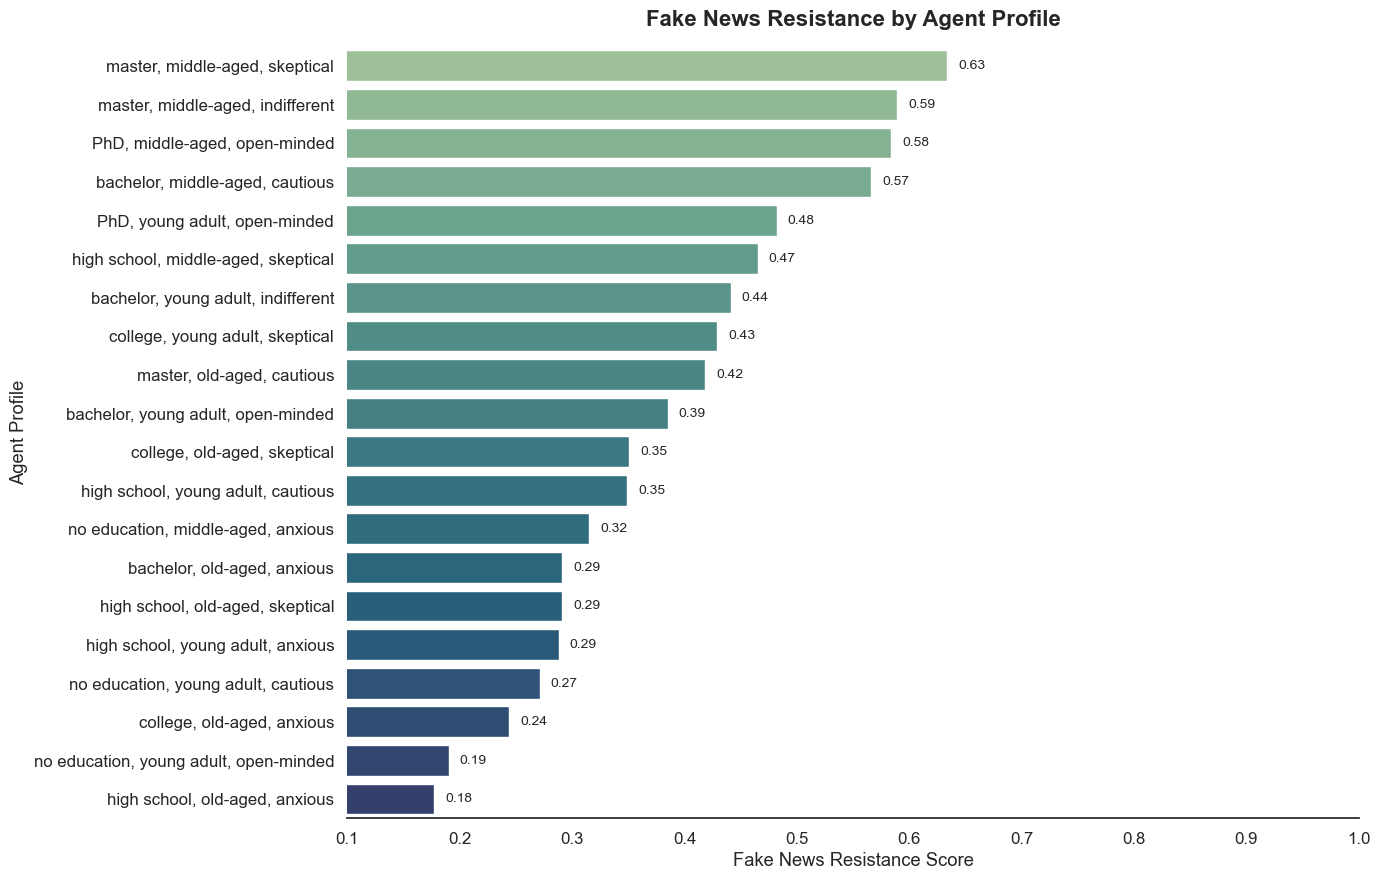

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Agent traits
EDUCATION_LEVELS = ["no education","high school", "college", "bachelor", "master", "PhD"]
AGE_GROUPS = ["old-aged", "young adult", "middle-aged"]  # middle-aged highest
PERSONALITIES = ["open-minded", "anxious", "indifferent", "cautious", "skeptical"]

# Scores: higher = more resistant to fake news
edu_score = {v: i for i, v in enumerate(EDUCATION_LEVELS)}
age_score = {"old-aged": 0, "young adult": 1, "middle-aged": 2}
pers_score = {"open-minded": 0, "anxious": 1, "indifferent": 2, "cautious": 3, "skeptical": 4}

# Generate 20 unique profiles
profiles = []
while len(profiles) < 20:
    profile = (
        random.choice(EDUCATION_LEVELS),
        random.choice(AGE_GROUPS),
        random.choice(PERSONALITIES)
    )
    if profile not in profiles:
        profiles.append(profile)

# Score each profile
data = []
for edu, age, pers in profiles:
    score = (
        0.5 * edu_score[edu] / (len(EDUCATION_LEVELS) - 1) +
        0.3 * age_score[age] / 2 +  # max is 2
        0.2 * pers_score[pers] / 4  # max is 4
    )
    resistance = 0.1 + 0.6 * score  # map to 0.3–0.9 range
    resistance += random.uniform(-0.02, 0.02)
    resistance = round(min(max(resistance, 0), 1), 3)
    label = f"{edu}, {age}, {pers}"
    data.append((label, resistance))

# Create DataFrame
df = pd.DataFrame(data, columns=["profile", "resistance_score"]).sort_values("resistance_score", ascending=False)

# Plot
sns.set(style="white", font_scale=1.1)
plt.figure(figsize=(14, 9))
ax = sns.barplot(
    data=df,
    x="resistance_score",
    y="profile",
    palette="crest",
    orient="h"
)

# Add labels
for i, val in enumerate(df["resistance_score"]):
    plt.text(val + 0.01, i, f"{val:.2f}", va='center', fontsize=10)

# Aesthetics
plt.title("Fake News Resistance by Agent Profile", fontsize=16, weight='bold', pad=15)
plt.xlabel("Fake News Resistance Score")
plt.ylabel("Agent Profile")
plt.xlim(0.1, 1.0)
sns.despine(left=True, top=True)
plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/3450127839.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


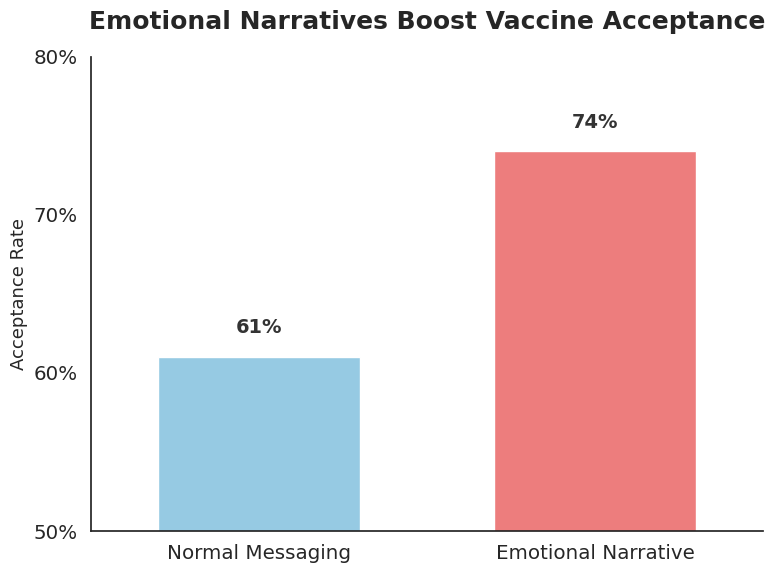

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = pd.DataFrame({
    "messaging_type": ["Normal Messaging", "Emotional Narrative"],
    "acceptance_rate": [0.61, 0.74]
})

# Style settings
sns.set(style="white", font="DejaVu Sans", font_scale=1.3)
colors = ["#89CFF0", "#FF6B6B"]  # calm blue and warm coral

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.barplot(
    data=data,
    x="messaging_type",
    y="acceptance_rate",
    palette=colors,
    width=0.6,
    ax=ax
)

# Rounded tops for bars (draw circles at the tops)
for bar in bars.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 0.015, f"{y:.0%}", ha='center', fontsize=14, weight='bold', color="#333333")

# Titles and labels
ax.set_title("Emotional Narratives Boost Vaccine Acceptance", fontsize=18, weight='bold', pad=20)
ax.set_xlabel("")
ax.set_ylabel("Acceptance Rate", fontsize=13)
ax.set_ylim(0.5, 0.8)
ax.set_yticks([0.5, 0.6, 0.7, 0.8])
ax.set_yticklabels(["50%", "60%", "70%", "80%"])

# Clean aesthetics
sns.despine()
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Optional: remove ticks for cleaner look
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/3589006360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


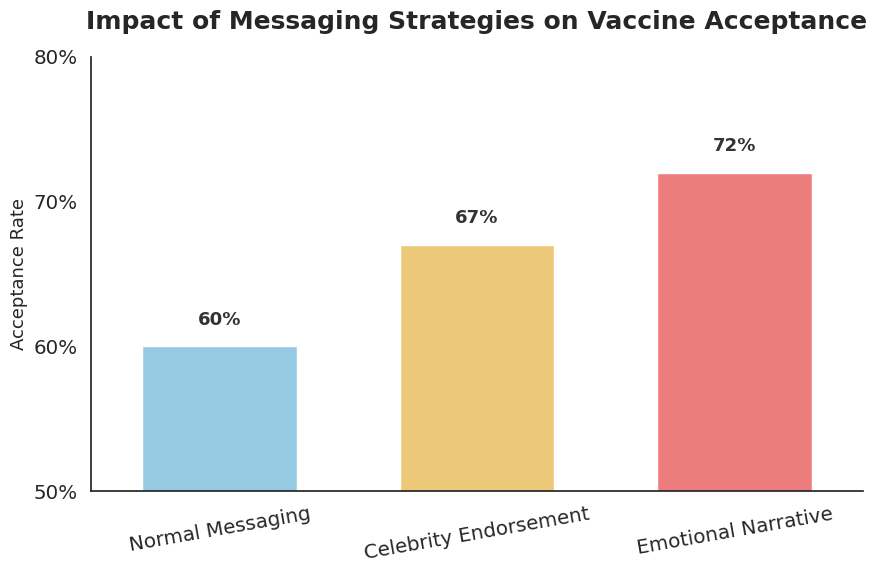

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = pd.DataFrame({
    "messaging_type": ["Normal Messaging", "Celebrity Endorsement", "Emotional Narrative"],
    "acceptance_rate": [0.60, 0.67, 0.72]
})

# Style
sns.set(style="white", font="DejaVu Sans", font_scale=1.3)
colors = ["#89CFF0", "#FFD166", "#FF6B6B"]  # blue, gold, coral

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = sns.barplot(
    data=data,
    x="messaging_type",
    y="acceptance_rate",
    palette=colors,
    width=0.6,
    ax=ax
)

# Add percent labels
for bar in bars.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 0.015, f"{y:.0%}", ha='center', fontsize=13, weight='bold', color="#333333")

# Titles and labels
ax.set_title("Impact of Messaging Strategies on Vaccine Acceptance", fontsize=18, weight='bold', pad=20)
ax.set_xlabel("")
ax.set_ylabel("Acceptance Rate", fontsize=13)
ax.set_ylim(0.5, 0.8)
ax.set_yticks([0.5, 0.6, 0.7, 0.8])
ax.set_yticklabels(["50%", "60%", "70%", "80%"])

# Aesthetics
sns.despine()
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(left=False, bottom=False)
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

/var/folders/qc/6dm3k1z10w33ynj64xfz__380000gn/T/ipykernel_56274/3834409809.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


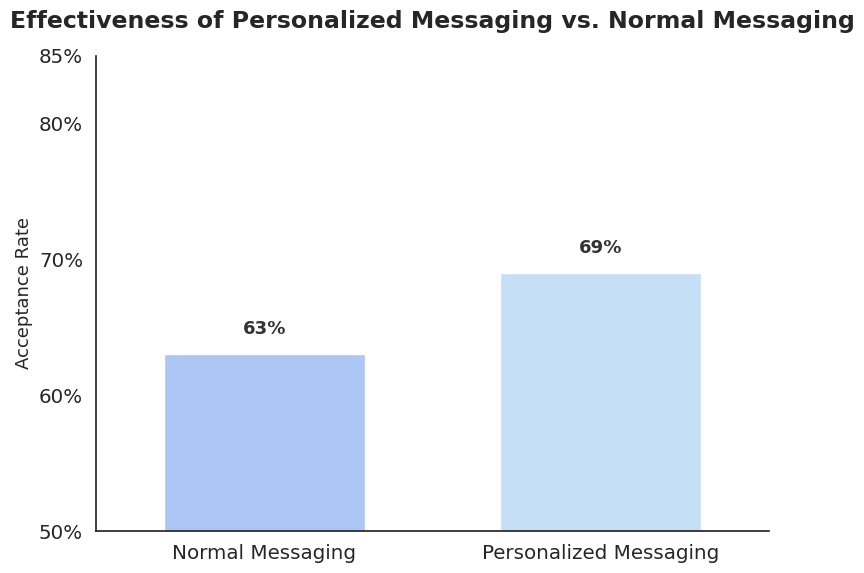

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = pd.DataFrame({
    "messaging_type": ["Normal Messaging", "Personalized Messaging"],
    "acceptance_rate": [0.63, 0.69]
})

# Style
sns.set(style="white", font="DejaVu Sans", font_scale=1.3)
colors = ["#A0C4FF", "#BDE0FE"]  # blue tones

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.barplot(
    data=data,
    x="messaging_type",
    y="acceptance_rate",
    palette=colors,
    width=0.6,
    ax=ax
)

# Add percentage labels
for bar in bars.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 0.015, f"{y:.0%}", ha='center', fontsize=13, weight='bold', color="#333333")

# Titles and labels
ax.set_title("Effectiveness of Personalized Messaging vs. Normal Messaging", fontsize=17, weight='bold', pad=20)
ax.set_xlabel("")
ax.set_ylabel("Acceptance Rate", fontsize=13)
ax.set_ylim(0.5, 0.85)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.85])
ax.set_yticklabels(["50%", "60%", "70%", "80%", "85%"])

# Aesthetics
sns.despine()
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()